# First CNN for Genre Classification

## Goal

Prepare Mel-spectrograms as image-like tensors and train a first simple convolutional neural network for music genre classification.

In [13]:
import numpy as np
import librosa
import librosa.display
from pathlib import Path
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [14]:
data_path = Path("../data/raw/gtzan/Data/genres_original")

In [15]:
genres = ["rock", "classical", "jazz", "metal"]

## Mel-Spectrogram Function

In [16]:
def compute_mel(file_path):

    y, sr = librosa.load(file_path, sr=22050)

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=128
    )

    mel_db = librosa.power_to_db(mel, ref=np.max)

    return mel_db

In [17]:
X = []
y = []

for genre in genres:

    genre_path = data_path / genre

    files = list(genre_path.glob("*.wav"))[:30]

    for file in files:

        mel = compute_mel(file)

        # feste Größe
        if mel.shape[1] >= 130:

            mel = mel[:, :130]

            X.append(mel)
            y.append(genre)

X = np.array(X)
y = np.array(y)

print("Dataset shape:", X.shape)

Dataset shape: (120, 128, 130)


## Channel Dimensions

In [18]:
X = X[:, np.newaxis, :, :]

print(X.shape)

(120, 1, 128, 130)


In [19]:
encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

print(y_encoded[:10])

[3 3 3 3 3 3 3 3 3 3]


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8)

loss_history = []

for epoch in range(5):
    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    loss_history.append(avg_loss)

    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

Epoch 1, Loss: 1.0450
Epoch 2, Loss: 0.1582
Epoch 3, Loss: 1.2539
Epoch 4, Loss: 0.5796
Epoch 5, Loss: 0.6052


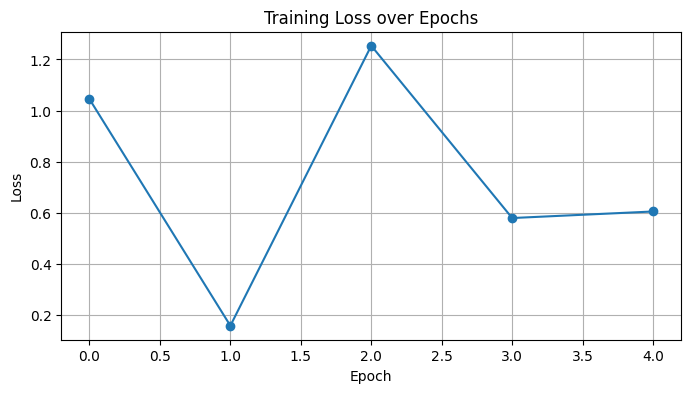

In [21]:
plt.figure(figsize=(8, 4))
plt.plot(loss_history, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss over Epochs")
plt.grid(True)
plt.show()

In [22]:
class SimpleCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv = nn.Conv2d(
            in_channels=1,
            out_channels=8,
            kernel_size=3
        )

        self.pool = nn.MaxPool2d(2)

        self.flatten = nn.Flatten()

        self.fc = nn.Linear(8 * 63 * 64, len(genres))

    def forward(self, x):

        x = self.conv(x)
        x = torch.relu(x)

        x = self.pool(x)

        x = self.flatten(x)

        x = self.fc(x)

        return x

In [23]:
model = SimpleCNN()

print(model)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

SimpleCNN(
  (conv): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Linear(in_features=32256, out_features=4, bias=True)
)


In [24]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.numpy())
        all_labels.extend(y_batch.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

accuracy = np.mean(all_preds == all_labels)
print("Test Accuracy:", accuracy)

Test Accuracy: 0.3333333333333333


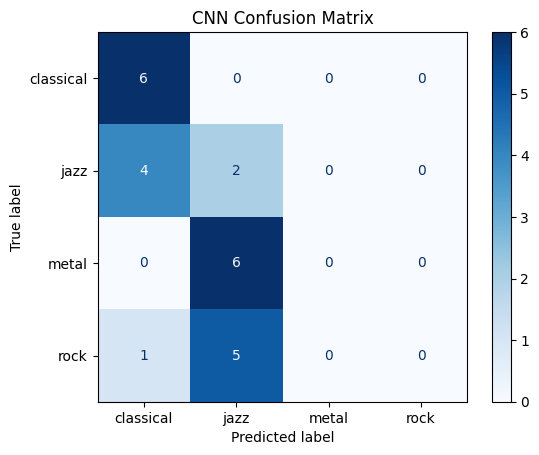

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

disp.plot(cmap="Blues")
plt.title("CNN Confusion Matrix")
plt.show()